Metrik Performa YOLOv11:
   varian   map50  map50_95
0    nano  0.8800    0.6953
1   small  0.8916    0.7105
2  medium  0.8976    0.7071


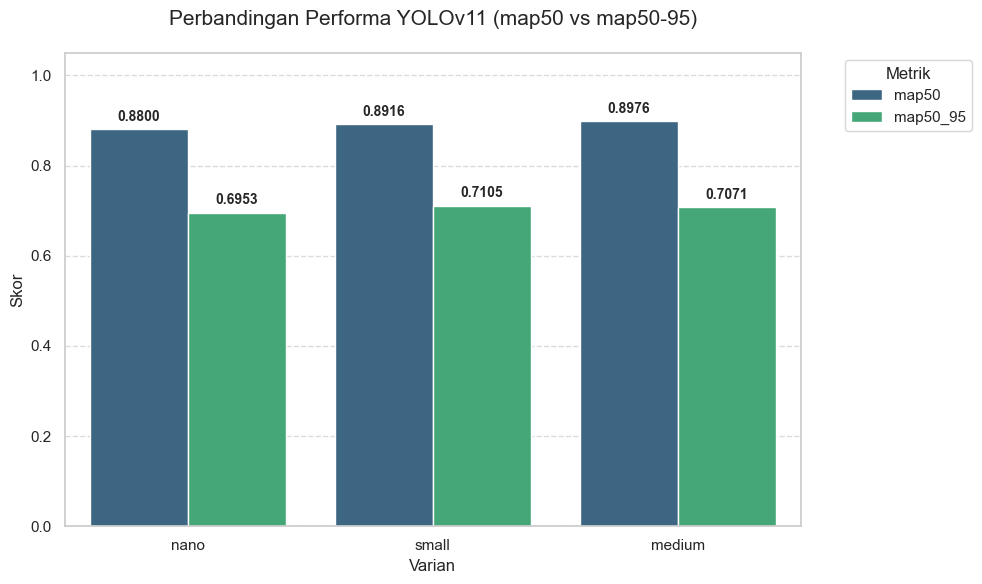

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data yang diekstrak dari gambar untuk YOLOv11
data = {
    'varian': ['nano', 'small', 'medium'],
    'map50': [0.8800, 0.8916, 0.8976],
    'map50_95': [0.6953, 0.7105, 0.7071]
}

df = pd.DataFrame(data)

# Cetak DataFrame
print("Metrik Performa YOLOv11:")
print(df)

# Siapkan data untuk plotting
df_melted = df.melt(id_vars='varian', var_name='metrik', value_name='skor')

# Buat plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Buat bar plot
ax = sns.barplot(data=df_melted, x='varian', y='skor', hue='metrik', palette='viridis')

# Tambahkan nilai di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

# Kustomisasi plot
plt.title('Perbandingan Performa YOLOv11 (map50 vs map50-95)', fontsize=15, pad=20)
plt.xlabel('Varian', fontsize=12)
plt.ylabel('Skor', fontsize=12)
plt.ylim(0, 1.05)  # Set batas sedikit di atas 1.0 untuk label
plt.legend(title='Metrik', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Metrik Latensi YOLOv11 (dalam ms):
       varian  p50 (Median)       p95
0    nano (n)       15.4600   19.7696
1   small (s)       47.4040   49.2380
2  medium (m)      128.4546  133.8748


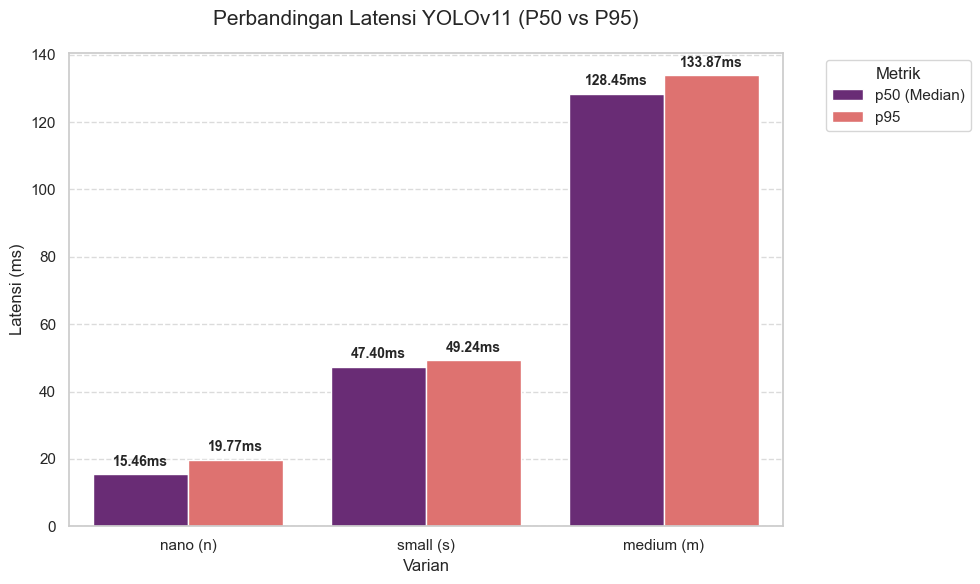

In [3]:
# Data latensi yang diekstrak dari gambar untuk YOLOv11
data_latensi = {
    'varian': ['nano (n)', 'small (s)', 'medium (m)'],
    'p50 (Median)': [15.4600, 47.4040, 128.4546],
    'p95': [19.7696, 49.2380, 133.8748]
}

df_latensi = pd.DataFrame(data_latensi)

# Cetak DataFrame latensi
print("Metrik Latensi YOLOv11 (dalam ms):")
print(df_latensi)

# Siapkan data untuk plotting
df_latensi_melted = df_latensi.melt(id_vars='varian', var_name='metrik', value_name='latensi')

# Buat plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Buat bar plot untuk latensi
ax = sns.barplot(data=df_latensi_melted, x='varian', y='latensi', hue='metrik', palette='magma')

# Tambahkan nilai di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}ms', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

# Kustomisasi plot
plt.title('Perbandingan Latensi YOLOv11 (P50 vs P95)', fontsize=15, pad=20)
plt.xlabel('Varian', fontsize=12)
plt.ylabel('Latensi (ms)', fontsize=12)
plt.legend(title='Metrik', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [4]:
# Gabungkan data performa dan latensi untuk YOLOv11
combined_data = {
    'varian': ['nano', 'small', 'medium'],
    'map50': [0.8800, 0.8916, 0.8976],
    'map50_95': [0.6953, 0.7105, 0.7071],
    'latency_p50_ms': [15.4600, 47.4040, 128.4546],
    'latency_p95_ms': [19.7696, 49.2380, 133.8748]
}

df_combined = pd.DataFrame(combined_data)

# Tampilkan DataFrame gabungan
print("Dataframe Gabungan Performa dan Latensi YOLOv11:")
display(df_combined)

Dataframe Gabungan Performa dan Latensi YOLOv11:


,varian,map50,map50_95,latency_p50_ms,latency_p95_ms
0,nano,0.8800,0.6953,15.4600,19.7696
1,small,0.8916,0.7105,47.4040,49.2380
2,medium,0.8976,0.7071,128.4546,133.8748


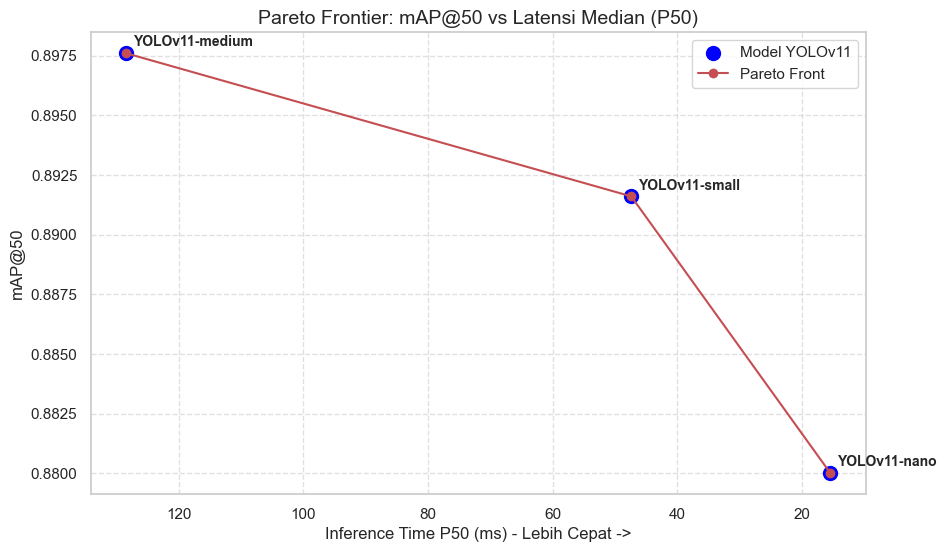

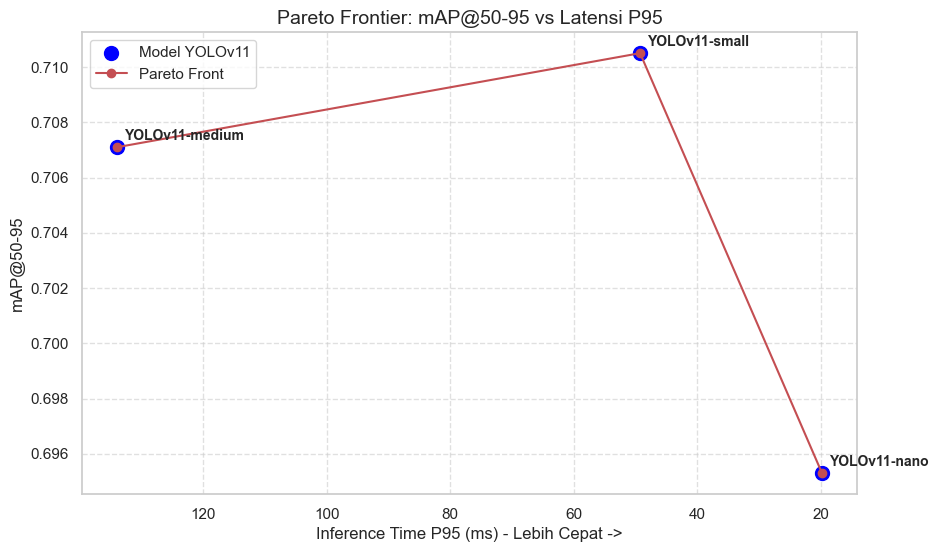

In [6]:
import matplotlib.pyplot as plt

# Gunakan data dari df_combined yang sudah dibuat sebelumnya
# df_combined = pd.DataFrame(combined_data)

def plot_pareto(x_col, y_col, x_label, y_label, title):
    plt.figure(figsize=(10, 6))
    
    # Urutkan berdasarkan latensi untuk menggambar garis frontier
    df_sorted = df_combined.sort_values(by=x_col)
    
    # Plot titik-titik
    plt.scatter(df_sorted[x_col], df_sorted[y_col], color='blue', s=100, label='Model YOLOv11')
    
    # Gambar garis Pareto Frontier (karena hanya 3 varian dan semuanya optimal secara trade-off)
    plt.plot(df_sorted[x_col], df_sorted[y_col], 'r-o', label='Pareto Front')
    
    # Tambahkan label untuk setiap titik
    for i, row in df_sorted.iterrows():
        plt.annotate(f"YOLOv11-{row['varian']}", 
                     (row[x_col], row[y_col]),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=10, fontweight='bold')
    
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Invert x-axis agar "lebih cepat" berada di sisi kanan (opsional, mengikuti gaya gambar contoh)
    plt.gca().invert_xaxis()
    
    plt.show()

# 1. Pareto Frontier: map50 vs p50 (Median)
plot_pareto('latency_p50_ms', 'map50', 
            'Inference Time P50 (ms) - Lebih Cepat ->', 'mAP@50', 
            'Pareto Frontier: mAP@50 vs Latensi Median (P50)')

# 2. Pareto Frontier: map50_95 vs p95
plot_pareto('latency_p95_ms', 'map50_95', 
            'Inference Time P95 (ms) - Lebih Cepat ->', 'mAP@50-95', 
            'Pareto Frontier: mAP@50-95 vs Latensi P95')